# Wczytanie modelu

# Przykładowe dane 

In [1]:
import os 
import cv2
data_test_path = "app/models/test_data"
IMAGE_SIZE = (640, 640)

list_images = os.listdir(data_test_path)
images = []
for item in list_images: 
    image_path = os.path.join(data_test_path, item)
    single_image = cv2.imread(image_path)
    single_image = cv2.resize(single_image, IMAGE_SIZE)

    images.append(single_image)

print(f"Number of images: {len(images)}")
print(f"Shape of images : {images[0].shape}")


Number of images: 8
Shape of images : (640, 640, 3)


# Detect plates: 

In [2]:
from app.models.prediction import DetectModels

In [4]:
detect = DetectModels(
    detect_car_plates_model_path = "app/models/best.pt")

image = images[7].copy() # example
plates_list, plates_images = detect.detection(image = image)

2026-02-09 21:35:08,292 [INFO] Initializing DetectModels...
2026-02-09 21:35:11,246 [INFO] DetectModels initialized successfully
2026-02-09 21:35:11,247 [INFO] Starting full detection pipeline



0: 640x640 1 number_plate, 5.3ms
Speed: 1.8ms preprocess, 5.3ms inference, 10.1ms postprocess per image at shape (1, 3, 640, 640)


2026-02-09 21:35:11,590 [INFO] Detected 1 plates in the image
2026-02-09 21:35:11,652 [INFO] Detection pipeline completed: 1 plates processed


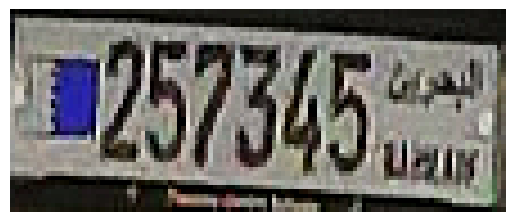

['72586;Vay']


In [5]:
import matplotlib.pyplot as plt 
if  len(plates_list) != 0: 
    img_plate = plates_images[0]
    plt.imshow(img_plate)
    plt.axis('off')
    plt.show()
    print(plates_list)
else: 
    print("Nie ma wykrytych tablic")